<a href="https://colab.research.google.com/github/tejaswantt/ensembl-annotation-analysis/blob/main/gsoc_2026_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Introduction**

Genome annotation describes the structural organization of genes within a genome, including the relationships between genes, transcripts, and exons.

Understanding these structural relationships is important for evaluating genome annotation quality and studying patterns of gene complexity.

Large bioinformatics platforms such as Ensembl provide detailed genome annotation datasets that allow researchers to analyze gene structure at a large scale.

This notebook presents an exploratory analysis of human genome annotation data obtained from an Ensembl GTF file.

The main objective of this analysis is to investigate structural relationships between genes, transcripts, and exons by computing several annotation metrics.

The analysis focuses on key genome annotation properties, including:

gene length distribution

number of transcripts per gene

exon counts within transcripts

transcript length distribution

In addition, the notebook examines relationships between these metrics by analyzing:

the correlation between gene length and transcript count

the correlation between transcript length and exon count

The notebook also visualizes the structural organization of a gene with a large number of transcripts to illustrate alternative transcript structures.

This exploratory analysis helps provide insights into genome annotation structure and serves as a foundation for developing reusable analysis modules for genome annotation metrics and comparative analysis across multiple species.

**Dataset**

The dataset used in this analysis is a genome annotation file obtained from Ensembl.

The data is provided in GTF (Gene Transfer Format), which contains information about genomic features such as genes, transcripts, and exons.

Each row in the dataset represents a genomic feature and includes attributes such as chromosome location, start position, end position, strand orientation, and additional metadata.

For this analysis, three main feature types were extracted from the dataset:

genes

transcripts

exons

These features follow a hierarchical structure where a gene contains multiple transcripts, and each transcript is composed of multiple exons.

The dataset is used to analyze genome structure by computing metrics such as gene length, transcript length, transcript counts per gene, and exon counts per transcript.

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Homo_sapiens.GRCh38.115.chr.gtf.gz to Homo_sapiens.GRCh38.115.chr.gtf.gz


In [3]:
import pandas as pd

gtf = pd.read_csv(
    "Homo_sapiens.GRCh38.115.chr.gtf.gz",
    sep="\t",
    comment="#",
    header=None
)

/tmp/ipykernel_221/1725428128.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  gtf = pd.read_csv(


In [4]:
gtf.head(5)

,0,1,2,3,4,5,6,7,8
0,1,ensembl_havana,gene,3069168,3438621,.,+,.,"gene_id ""ENSG00000142611""; gene_version ""17""; ..."
1,1,havana,transcript,3069168,3434342,.,+,.,"gene_id ""ENSG00000142611""; gene_version ""17""; ..."
2,1,havana,exon,3069168,3069296,.,+,.,"gene_id ""ENSG00000142611""; gene_version ""17""; ..."
3,1,havana,CDS,3069260,3069296,.,+,0,"gene_id ""ENSG00000142611""; gene_version ""17""; ..."
4,1,havana,start_codon,3069260,3069262,.,+,0,"gene_id ""ENSG00000142611""; gene_version ""17""; ..."


In [5]:
gtf.shape

(7746571, 9)

In [6]:
gtf.columns = [
    "chromosome",
    "source",
    "feature",
    "start",
    "end",
    "score",
    "strand",
    "frame",
    "attribute"
]

In [7]:
gtf.head()

,chromosome,source,feature,start,end,score,strand,frame,attribute
0,1,ensembl_havana,gene,3069168,3438621,.,+,.,"gene_id ""ENSG00000142611""; gene_version ""17""; ..."
1,1,havana,transcript,3069168,3434342,.,+,.,"gene_id ""ENSG00000142611""; gene_version ""17""; ..."
2,1,havana,exon,3069168,3069296,.,+,.,"gene_id ""ENSG00000142611""; gene_version ""17""; ..."
3,1,havana,CDS,3069260,3069296,.,+,0,"gene_id ""ENSG00000142611""; gene_version ""17""; ..."
4,1,havana,start_codon,3069260,3069262,.,+,0,"gene_id ""ENSG00000142611""; gene_version ""17""; ..."


**Data Preprocessing**

The GTF dataset was loaded into a pandas DataFrame for analysis.

Standard GTF column names were assigned to the dataset to make the data easier to work with.

The dataset was filtered to separate the main genomic feature types used in this analysis:

gene records

transcript records

exon records

Relevant identifiers such as gene IDs and transcript IDs were extracted from the attribute column.

Additional structural metrics were computed from the dataset, including:

gene length (gene end − gene start)

transcript length (transcript end − transcript start)

transcript counts per gene

exon counts per transcript

The processed datasets were then used for statistical analysis and visualization of genome annotation metrics.

In [8]:
genes = gtf[gtf['feature'] == "gene"]
transcripts = gtf[gtf['feature'] == "transcript"]
exons = gtf[gtf['feature'] == "exon"]

In [9]:
genes.head()


,chromosome,source,feature,start,end,score,strand,frame,attribute
0,1,ensembl_havana,gene,3069168,3438621,.,+,.,"gene_id ""ENSG00000142611""; gene_version ""17""; ..."
220,1,havana,gene,5301928,5307394,.,-,.,"gene_id ""ENSG00000284616""; gene_version ""1""; g..."
226,1,havana,gene,5492978,5494674,.,+,.,"gene_id ""ENSG00000260972""; gene_version ""1""; g..."
229,1,havana,gene,4175528,4175899,.,-,.,"gene_id ""ENSG00000229280""; gene_version ""1""; g..."
232,1,havana,gene,4571481,4594016,.,+,.,"gene_id ""ENSG00000232596""; gene_version ""3""; g..."


In [10]:
genes.shape


(78691, 9)

In [11]:
transcripts.shape


(507365, 9)

In [12]:

exons.shape

(3673949, 9)

**Annotation Metric Computation**

You can write it like this:

To understand the structural organization of genome annotations, several annotation metrics were computed from the processed dataset.

Gene length was calculated using the difference between the gene start and gene end positions.

Transcript length was computed using the start and end positions of each transcript.

Transcript counts per gene were determined by counting the number of transcripts associated with each gene.

Exon counts per transcript were calculated by counting the number of exons belonging to each transcript.

These metrics provide quantitative information about gene structure and transcript complexity, which can be further analyzed using statistical methods and visualizations.

In [13]:
genes["gene_length"] = genes['end'] - genes['start'] + 1

/tmp/ipykernel_221/473761602.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genes["gene_length"] = genes['end'] - genes['start'] + 1


In [14]:
genes["gene_length"].describe()

,gene_length
count,7.869100e+04
mean,3.149370e+04
std,8.615932e+04
min,8.000000e+00
25%,7.620000e+02
50%,4.627000e+03
75%,2.609200e+04
max,2.473539e+06


**Visualization and Distribution Analysis**

To better understand the structural properties of genome annotations, several visualizations were created based on the computed metrics.

These visualizations help reveal patterns in gene structure, transcript complexity, and exon organization.

The following analyses were performed:

distribution of gene lengths across the genome

relationship between transcript length and exon count

relationship between gene length and transcript count

These plots provide a clearer view of how structural genome features vary and how different annotation metrics are related.

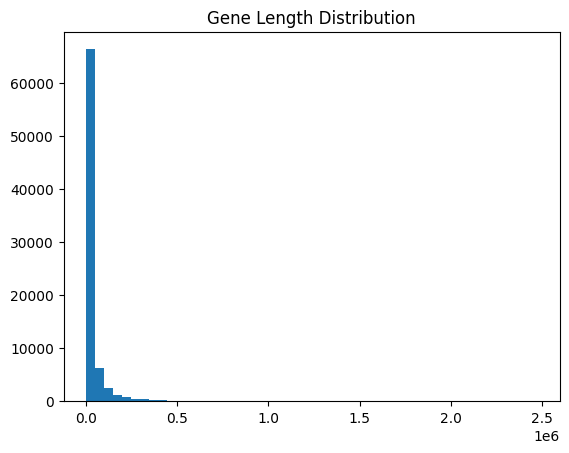

In [15]:
import matplotlib.pyplot as plt

plt.hist(genes["gene_length"], bins=50)
plt.title("Gene Length Distribution")
plt.show()

In [16]:
gtf["feature"].value_counts()

,count
feature,
exon,3673949
CDS,2283012
transcript,507365
five_prime_utr,426597
three_prime_utr,340566
start_codon,221109
stop_codon,215152
gene,78691
Selenocysteine,130


**Gene Length Distribution**

The following histogram shows the distribution of gene lengths in the genome.

Most genes are relatively short, while a smaller number of genes span very large genomic regions.

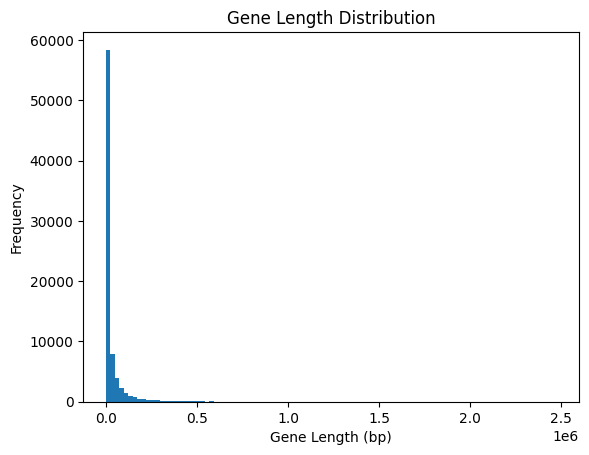

In [17]:
import matplotlib.pyplot as plt

plt.hist(genes["gene_length"], bins=100)
plt.title("Gene Length Distribution")
plt.xlabel("Gene Length (bp)")
plt.ylabel("Frequency")
plt.show()

In [18]:
genes = gtf[gtf["feature"] == "gene"].copy()

genes["gene_id"] = genes["attribute"].str.extract('gene_id "([^"]+)"')

In [19]:
genes[["gene_id", "start", "end"]].head()

,gene_id,start,end
0,ENSG00000142611,3069168,3438621
220,ENSG00000284616,5301928,5307394
226,ENSG00000260972,5492978,5494674
229,ENSG00000229280,4175528,4175899
232,ENSG00000232596,4571481,4594016


In [20]:
genes["gene_length"] = genes["end"] - genes["start"] + 1

In [21]:
genes[["gene_id","gene_length"]].head()

,gene_id,gene_length
0,ENSG00000142611,369454
220,ENSG00000284616,5467
226,ENSG00000260972,1697
229,ENSG00000229280,372
232,ENSG00000232596,22536


In [22]:
transcripts = gtf[gtf["feature"] == "transcript"].copy()

In [23]:
transcripts["gene_id"] = transcripts["attribute"].str.extract('gene_id "([^"]+)"')

In [24]:
transcripts_per_gene = transcripts.groupby("gene_id").size()

In [25]:
transcripts_per_gene.head()

,0
gene_id,
ENSG00000000003,13
ENSG00000000005,2
ENSG00000000419,22
ENSG00000000457,13
ENSG00000000460,22


In [26]:
genes = genes.merge(
    transcripts_per_gene.rename("transcript_count"),
    on="gene_id",
    how="left"
)

In [27]:
genes[["gene_id","gene_length","transcript_count"]].head()

,gene_id,gene_length,transcript_count
0,ENSG00000142611,369454,10
1,ENSG00000284616,5467,1
2,ENSG00000260972,1697,1
3,ENSG00000229280,372,1
4,ENSG00000232596,22536,8


**Gene Length vs Transcript Count**

This visualization explores the relationship between gene length and the number of transcripts produced by each gene.

It provides insight into how gene size may influence transcript diversity.

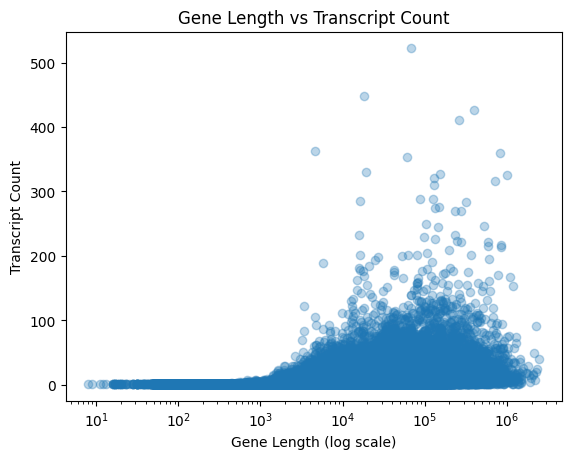

In [28]:
plt.scatter(genes["gene_length"], genes["transcript_count"], alpha=0.3)

plt.xscale("log")

plt.xlabel("Gene Length (log scale)")
plt.ylabel("Transcript Count")
plt.title("Gene Length vs Transcript Count")

plt.show()

In [29]:
longest_genes = genes.sort_values("gene_length", ascending=False)

In [30]:
longest_genes[["gene_id","gene_length","transcript_count"]].head(20)

,gene_id,gene_length,transcript_count
62073,ENSG00000078328,2473539,40
29294,ENSG00000174469,2304997,24
41539,ENSG00000153707,2298757,20
34093,ENSG00000198947,2241933,91
14533,ENSG00000185565,2195219,7
43755,ENSG00000150672,2173324,50
36462,ENSG00000183117,2059620,17
70184,ENSG00000172264,2057829,15
24704,ENSG00000188107,1987247,11
7366,ENSG00000168702,1899594,5


In [31]:
genes["gene_name"] = genes["attribute"].str.extract('gene_name "([^"]+)"')

In [32]:
genes[["gene_id","gene_name","gene_length"]].head()

,gene_id,gene_name,gene_length
0,ENSG00000142611,PRDM16,369454
1,ENSG00000284616,NaN,5467
2,ENSG00000260972,NaN,1697
3,ENSG00000229280,EEF1DP6,372
4,ENSG00000232596,LINC01646,22536


In [33]:
genes["gene_name"].isna().sum()

np.int64(35661)

In [34]:
genes["gene_name"] = genes["gene_name"].fillna(genes["gene_id"])

In [35]:
genes["gene_name"] = genes["attribute"].str.extract('gene_name "([^"]+)"')
genes["gene_name"] = genes["gene_name"].fillna(genes["gene_id"])

In [36]:
longest_genes = genes.sort_values("gene_length", ascending=False)

In [37]:
longest_genes[["gene_name","gene_length","transcript_count"]].head(20)

,gene_name,gene_length,transcript_count
62073,RBFOX1,2473539,40
29294,CNTNAP2,2304997,24
41539,PTPRD,2298757,20
34093,DMD,2241933,91
14533,LSAMP,2195219,7
43755,DLG2,2173324,50
36462,CSMD1,2059620,17
70184,MACROD2,2057829,15
24704,EYS,1987247,11
7366,LRP1B,1899594,5


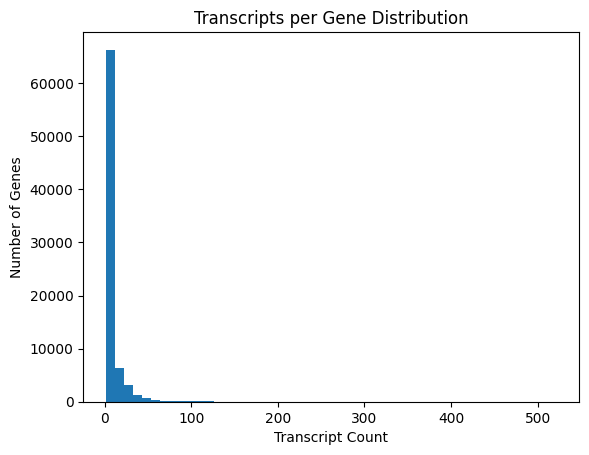

In [38]:
import matplotlib.pyplot as plt

plt.hist(genes["transcript_count"], bins=50)
plt.title("Transcripts per Gene Distribution")
plt.xlabel("Transcript Count")
plt.ylabel("Number of Genes")

plt.show()

In [39]:
exons = gtf[gtf["feature"] == "exon"].copy()

In [40]:
exons["transcript_id"] = exons["attribute"].str.extract('transcript_id "([^"]+)"')

In [41]:
exons_per_transcript = exons.groupby("transcript_id").size()

In [42]:
exons_per_transcript.head()

,0
transcript_id,
ENST00000000233,6
ENST00000000412,7
ENST00000000442,7
ENST00000001008,10
ENST00000001146,6


**Transcript Length vs Exon Count**

This scatter plot examines the relationship between transcript length and the number of exons.

It helps illustrate how transcript size relates to exon composition.

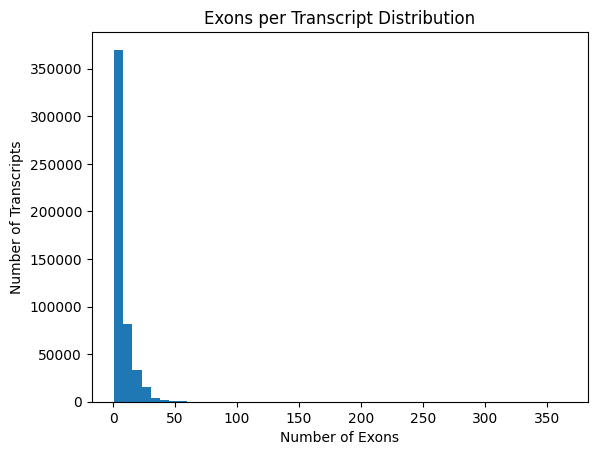

In [43]:
import matplotlib.pyplot as plt

plt.hist(exons_per_transcript, bins=50)

plt.title("Exons per Transcript Distribution")
plt.xlabel("Number of Exons")
plt.ylabel("Number of Transcripts")

plt.show()

In [44]:
transcripts = gtf[gtf["feature"] == "transcript"].copy()

transcripts["transcript_id"] = transcripts["attribute"].str.extract('transcript_id "([^"]+)"')

transcripts["transcript_length"] = transcripts["end"] - transcripts["start"] + 1

In [45]:
transcripts = gtf[gtf["feature"] == "transcript"].copy()

transcripts["transcript_id"] = transcripts["attribute"].str.extract('transcript_id "([^"]+)"')
transcripts["gene_id"] = transcripts["attribute"].str.extract('gene_id"([^"])"')
transcripts["transcript_length"] = transcripts["end"] - transcripts["start"]+1

In [46]:
exons_per_transcript = exons.groupby("transcript_id").size().reset_index(name="exon_count")

In [47]:
transcript_data = transcripts.merge(exons_per_transcript, on="transcript_id", how="left")

transcript_data = transcript_data[["transcript_id", "transcript_length", "exon_count"]]

In [48]:
transcript_data.head()

,transcript_id,transcript_length,exon_count
0,ENST00000511072,365175,16
1,ENST00000607632,117409,2
2,ENST00000378391,366225,17
3,ENST00000514189,365132,16
4,ENST00000270722,369419,17


In [49]:
genes[["gene_length","transcript_count"]].corr()

,gene_length,transcript_count
gene_length,1.000000,0.322729
transcript_count,0.322729,1.000000


In [50]:
transcript_data[["transcript_length","exon_count"]].corr()

,transcript_length,exon_count
transcript_length,1.00000,0.37049
exon_count,0.37049,1.00000


In [51]:
print("Average gene length:", genes["gene_length"].mean())
print("Average transcripts per gene:", genes["transcript_count"].mean())
print("Average transcript length:", transcript_data["transcript_length"].mean())
print("Average exons per transcript:", transcript_data["exon_count"].mean())

Average gene length: 31493.698847390428
Average transcripts per gene: 6.447560712152597
Average transcript length: 44568.55594493116
Average exons per transcript: 7.241234614133809


In [52]:
transcripts["gene_id"] = transcripts["attribute"].str.extract('gene_id "([^"]+)"')
exons["transcript_id"] = exons["attribute"].str.extract('transcript_id "([^"]+)"')

In [53]:
# Find the gene with the highest number of transcripts
top_gene = genes.sort_values("transcript_count", ascending=False).iloc[0]
top_gene_id = top_gene["gene_id"]

print("Top gene:", top_gene)

# Extract transcripts belonging to that gene
gene_transcripts = transcripts[transcripts["gene_id"] == top_gene_id]

# Extract exons belonging to those transcripts
gene_exons = exons[exons["transcript_id"].isin(gene_transcripts["transcript_id"])]

Top gene: chromosome                                                          7
source                                                  havana_tagene
feature                                                          gene
start                                                        74890240
end                                                          74959051
score                                                               .
strand                                                              +
frame                                                               .
attribute           gene_id "ENSG00000304176"; gene_version "1"; g...
gene_id                                               ENSG00000304176
gene_length                                                     68812
transcript_count                                                  522
gene_name                                             ENSG00000304176
Name: 31914, dtype: object


**Gene Structure Visualization**

This is where you explain the alternative splicing structure you plotted.

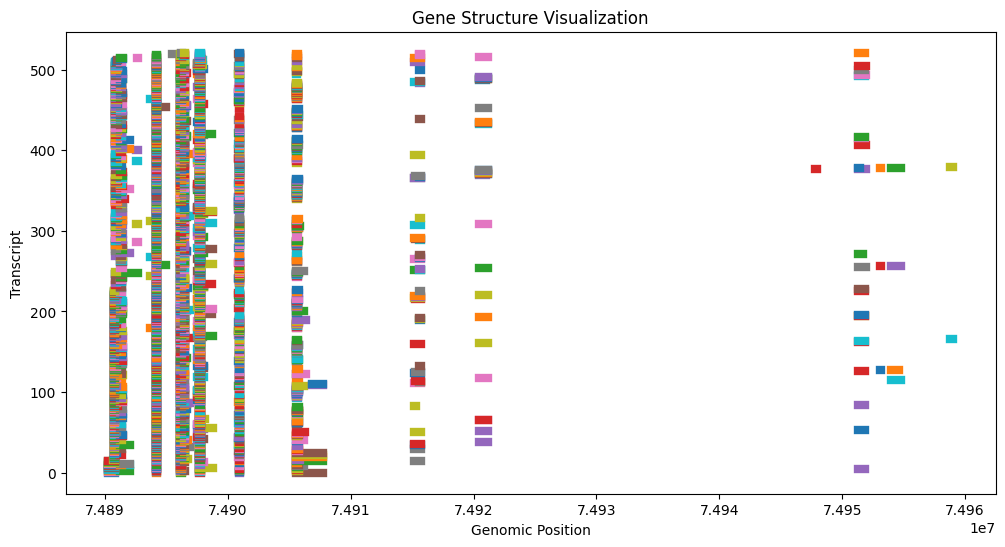

In [54]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,6))

for i, tid in enumerate(gene_transcripts["transcript_id"]):

    t_exons = gene_exons[gene_exons["transcript_id"] == tid]

    for _, exon in t_exons.iterrows():
        ax.plot([exon["start"], exon["end"]], [i, i], linewidth=6)

ax.set_xlabel("Genomic Position")
ax.set_ylabel("Transcript")
ax.set_title("Gene Structure Visualization")

plt.show()